# 🏆 World Cup 2026 — Predictor Round of 32 (partidos de hoy)
## Jueves 2 de julio de 2026
**Modelo:** API-Football + Elo histórico (martj42) + Poisson + Monte Carlo

Generalización del notebook USA vs Bosnia: mismo motor (Poisson + Monte Carlo, ratings ataque/defensa
desde xG, blend API + form histórica + Elo), pero parametrizado para correr sobre **varios partidos**
en lugar de uno solo hardcodeado.

**Partidos de hoy:**
1. 🇪🇸 España vs Austria 🇦🇹 — 3pm ET, SoFi Stadium (Inglewood, CA)
2. 🇵🇹 Portugal vs Croacia 🇭🇷 — 7pm ET, BMO Field (Toronto)
3. 🇨🇭 Suiza vs Argelia 🇩🇿 — 11pm ET, BC Place (Vancouver)

Ninguno de los tres es un anfitrión (USA/México/Canadá), así que **no aplica factor de localía real**
— solo un ligero ajuste por "home" nominal en la ficha del partido (viaje, aficionados, etc.), mucho
menor al 1.12 que usábamos para USA como anfitrión.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import poisson
import requests, warnings, os
from datetime import date

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Configuración ─────────────────────────────────────────────────────────────
API_KEY     = "YOUR_API_KEY"
BASE_URL    = "https://v3.football.api-sports.io"
HEADERS     = {"x-apisports-key": API_KEY}
WC_LEAGUE   = 1
WC_SEASON   = 2026

# Partidos de HOY — se resuelven por nombre, no por ID hardcodeado (más robusto
# que el notebook original: no dependemos de conocer el team_id de antemano)
MATCHES_TODAY = [
    ("Spain",       "Austria"),
    ("Portugal",    "Croatia"),
    ("Switzerland", "Algeria"),
]

HOST_NATIONS   = {"United States", "Mexico", "Canada"}
HOME_FACTOR_HOST    = 1.12   # ventaja real de anfitrión (no aplica hoy)
HOME_FACTOR_NOMINAL = 1.03   # ligera ventaja por ser "home" nominal en la ficha

N_SIMS      = 100_000
ELO_INIT    = 1500.0
ELO_K       = 32
TODAY       = date.today().isoformat()

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f7', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.35, 'grid.linestyle': '--',
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
})

def api(endpoint, params={}):
    """Llama a API-Football y devuelve response[]. Maneja errores."""
    r = requests.get(f"{BASE_URL}/{endpoint}", headers=HEADERS, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    if data.get('errors'):
        print(f"  API error: {data['errors']}")
    remaining = r.headers.get('x-ratelimit-requests-remaining', '?')
    print(f"  [{endpoint}] → {data.get('results', 0)} resultado(s) | calls restantes hoy: {remaining}")
    return data.get('response', [])

print("✓ Setup completo")
print(f"  Fecha: {TODAY} | Liga WC: {WC_LEAGUE} | Temporada: {WC_SEASON}")
print(f"  Partidos a predecir: {len(MATCHES_TODAY)}")
for h, a in MATCHES_TODAY:
    print(f"    - {h} vs {a}")


✓ Setup completo
  Fecha: 2026-07-02 | Liga WC: 1 | Temporada: 2026
  Partidos a predecir: 3
    - Spain vs Austria
    - Portugal vs Croatia
    - Switzerland vs Algeria


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


`api()` es el mismo wrapper central del notebook original. Lo que cambia es que ya no asumimos
IDs de equipo fijos (`USA_ID = 2`, `BIH_ID = 22`) — los resolvemos dinámicamente con `teams?search=`,
porque hoy trabajamos con 6 equipos distintos en 3 partidos, no con uno solo.


In [11]:
# ── Resolver team_id por nombre (cacheado) ───────────────────────────────────
_team_id_cache = {}

def get_team_id(name):
    """Busca el team_id de API-Football por nombre. Cachea resultados."""
    if name in _team_id_cache:
        return _team_id_cache[name]
    res = api("teams", {"search": name})
    if not res:
        print(f"  ⚠ No se encontró equipo para '{name}'")
        return None
    # Preferimos match exacto de nombre; si no, tomamos el primero
    exact = [t for t in res if t.get('team', {}).get('name', '').lower() == name.lower()]
    team = exact[0] if exact else res[0]
    tid = team['team']['id']
    _team_id_cache[name] = tid
    print(f"  {name} → team_id {tid} ({team['team'].get('country','')})")
    return tid

print("Resolviendo team IDs...\n")
team_ids = {}
for h, a in MATCHES_TODAY:
    for name in (h, a):
        if name not in team_ids:
            team_ids[name] = get_team_id(name)


Resolviendo team IDs...

  [teams] → 904 resultado(s) | calls restantes hoy: 93
  Spain → team_id 9 (Spain)
  [teams] → 411 resultado(s) | calls restantes hoy: 92
  Austria → team_id 775 (Austria)
  [teams] → 461 resultado(s) | calls restantes hoy: 91
  Portugal → team_id 27 (Portugal)
  [teams] → 209 resultado(s) | calls restantes hoy: 90
  Croatia → team_id 3 (Croatia)
  [teams] → 303 resultado(s) | calls restantes hoy: 89
  Switzerland → team_id 15 (Switzerland)
  [teams] → 230 resultado(s) | calls restantes hoy: 88
  Algeria → team_id 1532 (Algeria)


In [12]:
# ── Buscar el fixture de cada partido en WC 2026 ─────────────────────────────
def find_fixture(home_name, away_name):
    """Busca el fixture entre dos equipos en el Mundial 2026."""
    home_id = team_ids.get(home_name)
    if home_id is None:
        return None
    fixtures = api("fixtures", {"league": WC_LEAGUE, "season": WC_SEASON, "team": home_id})
    away_id = team_ids.get(away_name)
    for f in fixtures:
        teams = f.get('teams', {})
        h_id = teams.get('home', {}).get('id')
        a_id = teams.get('away', {}).get('id')
        if away_id in (h_id, a_id):
            return f
    return None

print("Buscando fixtures de hoy...\n")
fixtures_today = {}
for h, a in MATCHES_TODAY:
    print(f"  {h} vs {a}:")
    fx = find_fixture(h, a)
    if fx:
        fix_id    = fx['fixture']['id']
        fix_date  = fx['fixture']['date'][:10]
        fix_venue = fx['fixture'].get('venue', {}).get('name', 'N/A')
        fix_city  = fx['fixture'].get('venue', {}).get('city', '')
        fix_round = fx['league'].get('round', '')
        home_name = fx['teams']['home']['name']
        away_name = fx['teams']['away']['name']
        status    = fx['fixture']['status']['long']
        print(f"    Fixture ID {fix_id} · {home_name} vs {away_name} · {fix_date} · {fix_venue}, {fix_city} · {status}")
    else:
        print(f"    ⚠ Fixture no encontrado — usando defaults")
        fix_id, fix_date = None, TODAY
        home_name, away_name = h, a
        fix_venue, fix_city, fix_round = "N/A", "", "Round of 32"
    fixtures_today[(h, a)] = {
        'fix_id': fix_id, 'fix_date': fix_date, 'fix_venue': fix_venue,
        'fix_city': fix_city, 'fix_round': fix_round,
        'home_name': home_name, 'away_name': away_name,
    }


Buscando fixtures de hoy...

  Spain vs Austria:
  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [fixtures] → 0 resultado(s) | calls restantes hoy: ?
    ⚠ Fixture no encontrado — usando defaults
  Portugal vs Croatia:
  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [fixtures] → 0 resultado(s) | calls restantes hoy: ?
    ⚠ Fixture no encontrado — usando defaults
  Switzerland vs Algeria:
  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [fixtures] → 0 resultado(s) | calls restantes hoy: ?
    ⚠ Fixture no encontrado — usando defaults


In [13]:
# ── Team statistics desde API-Football (idéntico al original, ya generalizado) ─
def get_team_stats(team_id, name):
    """Extrae las métricas clave de /teams/statistics para el predictor."""
    if team_id is None:
        res = []
    else:
        res = api("teams/statistics", {
            "league": WC_LEAGUE, "season": WC_SEASON, "team": team_id
        })
    if not res:
        print(f"  Sin datos para {name} — usando defaults")
        return {
            'name': name, 'form': 'N/A',
            'gf_avg': 1.3, 'ga_avg': 1.1,
            'clean_sheets': 0, 'failed_to_score': 0,
            'wins': 0, 'draws': 0, 'losses': 0, 'played': 0,
            'biggest_win': 'N/A', 'biggest_loss': 'N/A',
            'pen_scored': 0, 'pen_total': 0,
            'formation': 'N/A', 'streak_wins': 0,
            'goals_by_minute': {},
        }
    s = res

    goals_for  = s.get('goals', {}).get('for', {})
    goals_ag   = s.get('goals', {}).get('against', {})
    fixtures   = s.get('fixtures', {})
    biggest    = s.get('biggest', {})
    penalty    = s.get('penalty', {})
    lineups    = s.get('lineups', [])

    top_formation = sorted(lineups, key=lambda x: x.get('played', 0), reverse=True)
    formation = top_formation[0]['formation'] if top_formation else 'N/A'

    return {
        'name':             name,
        'form':             s.get('form', 'N/A'),
        'gf_avg':           float(goals_for.get('average', {}).get('total', 1.3) or 1.3),
        'ga_avg':           float(goals_ag.get('average', {}).get('total', 1.1) or 1.1),
        'gf_total':         goals_for.get('total', {}).get('total', 0),
        'ga_total':         goals_ag.get('total', {}).get('total', 0),
        'clean_sheets':     s.get('clean_sheet', {}).get('total', 0),
        'failed_to_score':  s.get('failed_to_score', {}).get('total', 0),
        'wins':             fixtures.get('wins', {}).get('total', 0),
        'draws':            fixtures.get('draws', {}).get('total', 0),
        'losses':           fixtures.get('loses', {}).get('total', 0),
        'played':           fixtures.get('played', {}).get('total', 0),
        'biggest_win':      biggest.get('wins', {}).get('home') or biggest.get('wins', {}).get('away', 'N/A'),
        'biggest_loss':     biggest.get('loses', {}).get('away') or 'N/A',
        'pen_scored':       penalty.get('scored', {}).get('total', 0),
        'pen_total':        penalty.get('total', 0),
        'formation':        formation,
        'streak_wins':      biggest.get('streak', {}).get('wins', 0),
        'goals_by_minute':  goals_for.get('minute', {}),
    }

print("Descargando estadísticas.\n")
team_stats = {}
for name, tid in team_ids.items():
    team_stats[name] = get_team_stats(tid, name)

print("\n" + "="*55)
for s in team_stats.values():
    print(f"\n  {s['name']}")
    print(f"  Forma:          {s['form']}")
    print(f"  Partidos:       {s['played']} (W{s['wins']} D{s['draws']} L{s['losses']})")
    print(f"  Goles/partido:  {s['gf_avg']:.2f} a favor | {s['ga_avg']:.2f} en contra")
    print(f"  Formación:      {s['formation']}")
print("\n" + "="*55)


Descargando estadísticas de equipo para los 6 equipos de hoy...

  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [teams/statistics] → 0 resultado(s) | calls restantes hoy: ?
  Sin datos para Spain — usando defaults
  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [teams/statistics] → 0 resultado(s) | calls restantes hoy: ?
  Sin datos para Austria — usando defaults
  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [teams/statistics] → 0 resultado(s) | calls restantes hoy: ?
  Sin datos para Portugal — usando defaults
  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [teams/statistics] → 0 resultado(s) | calls restantes hoy: ?
  Sin datos para Croatia — usando defaults
  API error: {'plan': 'Free plans do not have access to this season, try from 2022 to 2024.'}
  [teams/statistics] → 0 resultado(s) | ca

`get_team_stats()` es exactamente la misma función del notebook original — no necesitaba cambios,
ya recibía `team_id` y `name` como parámetros. Ahora simplemente la llamamos una vez por cada uno
de los 6 equipos en juego hoy, guardando todo en el diccionario `team_stats`.


In [14]:
# ── Alineaciones e injuries por partido ──────────────────────────────────────
def get_lineups(fixture_id):
    if fixture_id is None:
        return {}
    res = api("fixtures/lineups", {"fixture": fixture_id})
    if not res:
        return {}
    out = {}
    for team_data in res:
        name = team_data.get('team', {}).get('name', 'Unknown')
        formation = team_data.get('formation', 'N/A')
        starters = [p['player']['name'] for p in team_data.get('startXI', [])]
        subs     = [p['player']['name'] for p in team_data.get('substitutes', [])]
        out[name] = {'formation': formation, 'starters': starters, 'subs': subs}
    return out

def get_injuries(fixture_id):
    if fixture_id is None:
        return {}
    res = api("injuries", {"fixture": fixture_id})
    if not res:
        return {}
    out = {}
    for p in res:
        team = p.get('team', {}).get('name', 'Unknown')
        player = p.get('player', {}).get('name', '')
        reason = p.get('player', {}).get('reason', '')
        out.setdefault(team, []).append({'player': player, 'reason': reason})
    return out

# Factor de ajuste manual por bajas — edita aquí si hay una estrella confirmada fuera
# ej. INJURY_FACTOR['Croatia'] = 0.90 si Modric no juega
INJURY_FACTOR = {}

print("Consultando alineaciones e injuries por partido...\n")
for h, a in MATCHES_TODAY:
    info = fixtures_today[(h, a)]
    lu = get_lineups(info['fix_id'])
    inj = get_injuries(info['fix_id'])
    info['lineups'], info['injuries'] = lu, inj
    print(f"\n  {h} vs {a}")
    for team_name in (info['home_name'], info['away_name']):
        if team_name in lu:
            print(f"    {team_name}: formación {lu[team_name]['formation']}, "
                  f"titulares confirmados")
        else:
            print(f"    {team_name}: alineación no disponible aún")
        if team_name in inj:
            print(f"    Bajas ({len(inj[team_name])}): " +
                  ", ".join(p['player'] for p in inj[team_name]))
        INJURY_FACTOR.setdefault(team_name, 1.0)


Consultando alineaciones e injuries por partido...


  Spain vs Austria
    Spain: alineación no disponible aún
    Austria: alineación no disponible aún

  Portugal vs Croatia
    Portugal: alineación no disponible aún
    Croatia: alineación no disponible aún

  Switzerland vs Algeria
    Switzerland: alineación no disponible aún
    Algeria: alineación no disponible aún


Igual que en el original: las alineaciones solo aparecen ~1h antes del kickoff. Si Suiza-Argelia
juega a las 11pm ET, cuando corras esto en la mañana probablemente salga vacío para ese partido —
normal, el modelo sigue funcionando con los stats del torneo. `INJURY_FACTOR` es el único diccionario
que edites a mano si confirman una baja importante.


In [15]:
# ── Elo histórico desde martj42/international_results (una sola carga, se reusa) ─
print("Descargando historial de resultados (martj42 GitHub)...\n")

HIST_URL = ("https://raw.githubusercontent.com/martj42/international_results"
            "/master/results.csv")
NAME_MAP = {
    "USA": "United States", "Korea Republic": "South Korea",
    "Türkiye": "Turkey", "Côte d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic", "Curaçao": "Curacao",
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegowina": "Bosnia and Herzegovina",
}

df = pd.read_csv(HIST_URL, parse_dates=['date'])
df['home_team'] = df['home_team'].map(lambda x: NAME_MAP.get(x, x))
df['away_team'] = df['away_team'].map(lambda x: NAME_MAP.get(x, x))
df = df.dropna(subset=['home_score','away_score'])
df = df[df['date'] >= '2000-01-01'].sort_values('date').reset_index(drop=True)
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)
df['neutral']    = df['neutral'].astype(str).str.upper().eq('TRUE')
print(f"✓ {len(df):,} partidos cargados (2000–{df['date'].max().date()})")

def k_factor(tournament):
    t = str(tournament).lower()
    if 'fifa world cup' in t and 'qualif' not in t: return 60
    if 'qualif' in t:                               return 40
    if any(x in t for x in ['copa','euro','africa cup','gold cup','nations']): return 50
    if 'friendly' in t:                             return 20
    return 35

def compute_elo(df):
    ratings = {}
    for _, row in df.iterrows():
        h, a = row['home_team'], row['away_team']
        gh, ga = row['home_score'], row['away_score']
        elo_h = ratings.get(h, ELO_INIT)
        elo_a = ratings.get(a, ELO_INIT)
        bonus = 0 if row['neutral'] else 50
        exp_h = 1 / (1 + 10 ** -((elo_h + bonus - elo_a) / 400))
        res_h = 1.0 if gh > ga else (0.5 if gh == ga else 0.0)
        k     = k_factor(row.get('tournament',''))
        gdf   = min(abs(gh - ga), 3) * 0.1 + 1
        ratings[h] = elo_h + k * gdf * (res_h - exp_h)
        ratings[a] = elo_a + k * gdf * ((1 - res_h) - (1 - exp_h))
    return ratings

print("Calculando Elo (puede tomar ~10 seg)...", end=' ')
elo = compute_elo(df)
print("✓")

print("\nElo de los equipos en juego hoy:")
for name in team_ids:
    print(f"  {name:<14} {elo.get(name, ELO_INIT):.0f}")


Descargando historial de resultados (martj42 GitHub)...

✓ 25,425 partidos cargados (2000–2026-07-01)
Calculando Elo (puede tomar ~10 seg)... ✓

Elo de los equipos en juego hoy:
  Spain          2097
  Austria        1814
  Portugal       1964
  Croatia        1891
  Switzerland    1883
  Algeria        1847


Este bloque no cambió respecto al original — el Elo se calcula **una sola vez** sobre todo el
historial y se reutiliza para los 3 partidos, en vez de recalcularlo por partido (sería 3x trabajo
innecesario ya que la tabla `ratings` final es la misma pase lo que pase después).


In [16]:
# ── Head to Head + forma reciente (funciones genéricas, ya parametrizadas por nombre) ─
H2H_WEIGHT = 0.10

def head_to_head(team_a, team_b):
    mask = (
        ((df['home_team'] == team_a) & (df['away_team'] == team_b)) |
        ((df['home_team'] == team_b) & (df['away_team'] == team_a))
    )
    h2h = df[mask].copy()
    if len(h2h) == 0:
        return h2h, 0.5
    a_wins = (((h2h['home_team']==team_a) & (h2h['home_score']>h2h['away_score'])).sum() +
              ((h2h['away_team']==team_a) & (h2h['away_score']>h2h['home_score'])).sum())
    winrate_a = a_wins / len(h2h)
    return h2h, winrate_a

def recent_form(team, n=10, decay=0.85):
    mask = (df['home_team'] == team) | (df['away_team'] == team)
    recent = df[mask].sort_values('date').tail(n)
    if recent.empty:
        return {'gf': 1.3, 'ga': 1.1}
    gf_list, ga_list = [], []
    for _, row in recent.iterrows():
        if row['home_team'] == team:
            gf_list.append(row['home_score']); ga_list.append(row['away_score'])
        else:
            gf_list.append(row['away_score']); ga_list.append(row['home_score'])
    w = np.array([decay**(len(gf_list)-1-i) for i in range(len(gf_list))])
    w /= w.sum()
    return {'gf': round(np.dot(w, gf_list), 3), 'ga': round(np.dot(w, ga_list), 3)}

team_form = {name: recent_form(name) for name in team_ids}
print("Forma reciente (últimos 10 partidos, ponderada):")
for name, f in team_form.items():
    print(f"  {name:<14} GF/pg={f['gf']:.2f}  GA/pg={f['ga']:.2f}")


Forma reciente (últimos 10 partidos, ponderada):
  Spain          GF/pg=1.97  GA/pg=0.33
  Austria        GF/pg=2.21  GA/pg=1.22
  Portugal       GF/pg=2.14  GA/pg=0.59
  Croatia        GF/pg=1.72  GA/pg=1.53
  Switzerland    GF/pg=2.12  GA/pg=1.08
  Algeria        GF/pg=2.11  GA/pg=1.29


In [20]:
# ── λ, Monte Carlo, prórroga/penales y dashboard — todo en una función reusable ─

AVG_WC_GOALS = 2.52

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f7',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',

    # texto visible
    'text.color': '#1a1a1a',
    'axes.labelcolor': '#1a1a1a',
    'axes.titlecolor': '#1a1a1a',
    'xtick.color': '#1a1a1a',
    'ytick.color': '#1a1a1a',
    'legend.labelcolor': '#1a1a1a'
})


def get_lambda(attacker_stats, defender_stats, attacker_form, defender_form,
               elo_att, elo_def, home_factor=1.0, injury_factor=1.0):
    gf_api = attacker_stats.get('gf_avg', AVG_WC_GOALS)
    ga_api = defender_stats.get('ga_avg', AVG_WC_GOALS)
    lam_api = (gf_api / AVG_WC_GOALS) * (ga_api / AVG_WC_GOALS) * AVG_WC_GOALS

    gf_hist = attacker_form['gf']
    ga_hist = defender_form['ga']
    lam_hist = (gf_hist / AVG_WC_GOALS) * (ga_hist / AVG_WC_GOALS) * AVG_WC_GOALS

    elo_ratio = 10 ** ((elo_att - elo_def) / 800)
    lam_elo = AVG_WC_GOALS * elo_ratio

    lam = 0.50 * lam_api + 0.35 * lam_hist + 0.15 * lam_elo
    lam *= home_factor
    lam *= injury_factor

    return round(max(lam, 0.2), 3)


def simulate_match(home_name, away_name, C=('#B22234', '#002395')):
    info = fixtures_today[(home_name, away_name)]

    s_h, s_a = team_stats[home_name], team_stats[away_name]
    f_h, f_a = team_form[home_name], team_form[away_name]
    elo_h, elo_a = elo.get(home_name, ELO_INIT), elo.get(away_name, ELO_INIT)

    home_factor = HOME_FACTOR_HOST if home_name in HOST_NATIONS else HOME_FACTOR_NOMINAL

    lam_h = get_lambda(
        s_h, s_a, f_h, f_a, elo_h, elo_a,
        home_factor=home_factor,
        injury_factor=INJURY_FACTOR.get(home_name, 1.0)
    )

    lam_a = get_lambda(
        s_a, s_h, f_a, f_h, elo_a, elo_h,
        home_factor=1.0,
        injury_factor=INJURY_FACTOR.get(away_name, 1.0)
    )

    gh = np.random.poisson(lam_h, N_SIMS)
    ga = np.random.poisson(lam_a, N_SIMS)

    p_h = np.mean(gh > ga)
    p_d = np.mean(gh == ga)
    p_a = np.mean(gh < ga)

    total = gh + ga
    over25 = np.mean(total > 2.5)
    over35 = np.mean(total > 3.5)
    btts = np.mean((gh > 0) & (ga > 0))

    scores = pd.Series([f"{h}-{a}" for h, a in zip(gh, ga)])

    top_sc = (
        scores.value_counts(normalize=True)
        .head(8)
        .rename_axis('score')
        .reset_index(name='prob')
    )

    corners_h = round(lam_h * 1.9 + 0.4 * (lam_h - lam_a), 1)
    corners_a = round(lam_a * 1.9 + 0.4 * (lam_a - lam_h), 1)

    # Prórroga y penales
    p_pen_h = 0.51 if elo_h >= elo_a else 0.49
    p_pen_a = 1 - p_pen_h

    et_resolves = p_d * 0.50

    p_h_total = (
            p_h
            + et_resolves * p_pen_h
            + et_resolves * (lam_h / (lam_h + lam_a))
    )

    p_a_total = (
            p_a
            + et_resolves * p_pen_a
            + et_resolves * (lam_a / (lam_h + lam_a))
    )

    conf = max(p_h, p_a)
    tag = "LOCK" if conf >= 0.60 else ("LEAN" if conf >= 0.45 else "TOSS-UP")
    pick = home_name if p_h > p_a else away_name

    result = {
        'home': home_name,
        'away': away_name,
        'lam_h': lam_h,
        'lam_a': lam_a,
        'elo_h': elo_h,
        'elo_a': elo_a,
        'p_h': p_h,
        'p_d': p_d,
        'p_a': p_a,
        'p_h_total': p_h_total,
        'p_a_total': p_a_total,
        'over25': over25,
        'over35': over35,
        'btts': btts,
        'corners_h': corners_h,
        'corners_a': corners_a,
        'pick': pick,
        'tag': tag,
        'conf': conf,
        'top_score': top_sc.iloc[0]['score'],
        'top_score_prob': top_sc.iloc[0]['prob']
    }

    # ── Dashboard ──
    fig = plt.figure(figsize=(16, 10), facecolor='white')

    fig.suptitle(
        f"{home_name} vs {away_name}\n"
        f"FIFA World Cup 2026 · {info['fix_round']} · {info['fix_venue']}, {info['fix_city']}",
        fontsize=16,
        fontweight='bold',
        color='#1a1a1a',
        y=0.98
    )

    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.50,
        wspace=0.38
    )

    # 1. Resultado 90 minutos
    ax1 = fig.add_subplot(gs[0, 0])

    labels = [f'{home_name}\ngana', 'Empate', f'{away_name}\ngana']
    probs = [p_h, p_d, p_a]

    bars = ax1.bar(
        labels,
        [p * 100 for p in probs],
        color=[C[0], '#6b7280', C[1]],
        alpha=0.88,
        width=0.55
    )

    for b, p in zip(bars, probs):
        ax1.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.8,
            f'{p:.1%}',
            ha='center',
            fontsize=11,
            fontweight='bold',
            color='#1a1a1a'
        )

    ax1.set_ylim(0, max(probs) * 100 + 14)
    ax1.set_ylabel('Probabilidad (%)')
    ax1.set_title('Resultado en 90 minutos', color='#1a1a1a')

    # 2. Marcadores más probables
    ax2 = fig.add_subplot(gs[0, 1])

    bar_c = []

    for sc in top_sc['score']:
        hg, ag = map(int, sc.split('-'))

        if hg > ag:
            bar_c.append(C[0])
        elif ag > hg:
            bar_c.append(C[1])
        else:
            bar_c.append('#6b7280')

    ax2.bar(
        top_sc['score'],
        top_sc['prob'] * 100,
        color=bar_c,
        alpha=0.85
    )

    ax2.set_xlabel('Marcador')
    ax2.set_ylabel('Probabilidad (%)')
    ax2.set_title('Marcadores más probables', color='#1a1a1a')
    ax2.tick_params(axis='x', rotation=35)

    patches = [
        mpatches.Patch(color=C[0], label=home_name),
        mpatches.Patch(color='#6b7280', label='Empate'),
        mpatches.Patch(color=C[1], label=away_name)
    ]

    ax2.legend(handles=patches, fontsize=8)

    # 3. Métricas
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis('off')

    metrics = [
        ('xG ' + home_name, f'{lam_h:.2f}'),
        ('xG ' + away_name, f'{lam_a:.2f}'),
        ('Over 2.5', f'{over25:.1%}'),
        ('Over 3.5', f'{over35:.1%}'),
        ('BTTS', f'{btts:.1%}'),
        ('Córners ' + home_name, f'{corners_h:.1f}'),
        ('Córners ' + away_name, f'{corners_a:.1f}'),
        ('Elo ' + home_name, f'{elo_h:.0f}'),
        ('Elo ' + away_name, f'{elo_a:.0f}'),
        ('Pick', f'{pick} ({tag})')
    ]

    for i, (label, val) in enumerate(metrics):
        y = 0.95 - i * 0.095

        if home_name in label:
            color = C[0]
        elif away_name in label:
            color = C[1]
        else:
            color = '#1a1a2e'

        ax3.text(
            0.05,
            y,
            label,
            transform=ax3.transAxes,
            fontsize=10,
            color='#333333'
        )

        ax3.text(
            0.65,
            y,
            val,
            transform=ax3.transAxes,
            fontsize=10,
            fontweight='bold',
            color=color
        )

    ax3.set_title('Métricas del modelo', color='#1a1a1a')

    # 4. Probabilidad de pasar de ronda
    ax4 = fig.add_subplot(gs[1, 0])

    bars4 = ax4.bar(
        [home_name, away_name],
        [p_h_total * 100, p_a_total * 100],
        color=[C[0], C[1]],
        alpha=0.88,
        width=0.5
    )

    for b, p in zip(bars4, [p_h_total, p_a_total]):
        ax4.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.8,
            f'{p:.1%}',
            ha='center',
            fontsize=11,
            fontweight='bold',
            color='#1a1a1a'
        )

    ax4.set_ylim(0, 105)
    ax4.set_ylabel('Probabilidad (%)')
    ax4.set_title('Probabilidad de pasar de ronda\nIncluye prórroga y penales', color='#1a1a1a')

    # 5. Distribución de goles totales
    ax5 = fig.add_subplot(gs[1, 1])

    vals, edges = np.histogram(total, bins=range(0, 10))

    ax5.bar(
        edges[:-1],
        vals / N_SIMS * 100,
        color='#1baf7a',
        alpha=0.85,
        width=0.7
    )

    ax5.axvline(2.5, color='red', ls='--', alpha=0.6, label='Línea 2.5')
    ax5.axvline(3.5, color='orange', ls='--', alpha=0.6, label='Línea 3.5')

    ax5.set_xlabel('Goles totales')
    ax5.set_ylabel('Probabilidad (%)')
    ax5.set_title('Distribución de goles totales', color='#1a1a1a')
    ax5.legend(fontsize=8)

    # 6. Comparativa de estadísticas
    ax6 = fig.add_subplot(gs[1, 2])

    cat = [
        'GF/pg\n(torneo)',
        'GA/pg\n(torneo)',
        'Form GF\n(hist)',
        'Form GA\n(hist)',
        'λ final'
    ]

    v_h = [s_h['gf_avg'], s_h['ga_avg'], f_h['gf'], f_h['ga'], lam_h]
    v_a = [s_a['gf_avg'], s_a['ga_avg'], f_a['gf'], f_a['ga'], lam_a]

    x = np.arange(len(cat))
    w = 0.35

    ax6.bar(
        x - w / 2,
        v_h,
        w,
        color=C[0],
        alpha=0.85,
        label=home_name
    )

    ax6.bar(
        x + w / 2,
        v_a,
        w,
        color=C[1],
        alpha=0.85,
        label=away_name
    )

    ax6.set_xticks(x)
    ax6.set_xticklabels(cat, fontsize=8)
    ax6.set_ylabel('Goles')
    ax6.set_title('Comparativa de estadísticas', color='#1a1a1a')
    ax6.legend(fontsize=9)

    # Limpieza visual general
    for ax in [ax1, ax2, ax4, ax5, ax6]:
        ax.tick_params(colors='#1a1a1a')
        ax.xaxis.label.set_color('#1a1a1a')
        ax.yaxis.label.set_color('#1a1a1a')

    # Guardar y mostrar
    fname = f"{home_name.replace(' ', '_')}_vs_{away_name.replace(' ', '_')}_{TODAY}.png"

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    plt.savefig(
        fname,
        bbox_inches='tight',
        dpi=130,
        facecolor='white'
    )

    plt.show()

    print(f"✓ Guardado: {fname}")

    print()
    print("=" * 58)
    print(f"  {home_name} vs {away_name}")
    print(f"  {info['fix_round']} · {info['fix_venue']} · {info['fix_date']}")
    print("=" * 58)
    print(f"  λ {home_name}  {lam_h:.3f}   λ {away_name} {lam_a:.3f}")
    print(f"  Elo {home_name}  {elo_h:.0f}    Elo {away_name} {elo_a:.0f}")
    print("-" * 58)
    print(f"  {home_name} gana (90 min)   {p_h:.1%}")
    print(f"  Empate (90 min)             {p_d:.1%}")
    print(f"  {away_name} gana (90 min)   {p_a:.1%}")
    print("-" * 58)
    print(f"  {home_name} pasa de ronda   {p_h_total:.1%}")
    print(f"  {away_name} pasa de ronda   {p_a_total:.1%}")
    print("-" * 58)
    print(f"  Over 2.5   {over25:.1%}   |   BTTS   {btts:.1%}")
    print("=" * 58)
    print(f"  PICK: {pick} — {tag}")
    print("=" * 58)

    return result


`simulate_match()` empaqueta todo lo que antes eran ~6 celdas separadas para USA-Bosnia (λ, Monte
Carlo, prórroga/penales, dashboard, resumen) en una sola función parametrizada por `home_name` y
`away_name`. Así corremos exactamente el mismo motor tres veces sin copiar/pegar código — la única
diferencia real entre partidos es qué datos entran (stats, Elo, forma), no la lógica del modelo.



############################################################
#  Spain vs Austria
############################################################



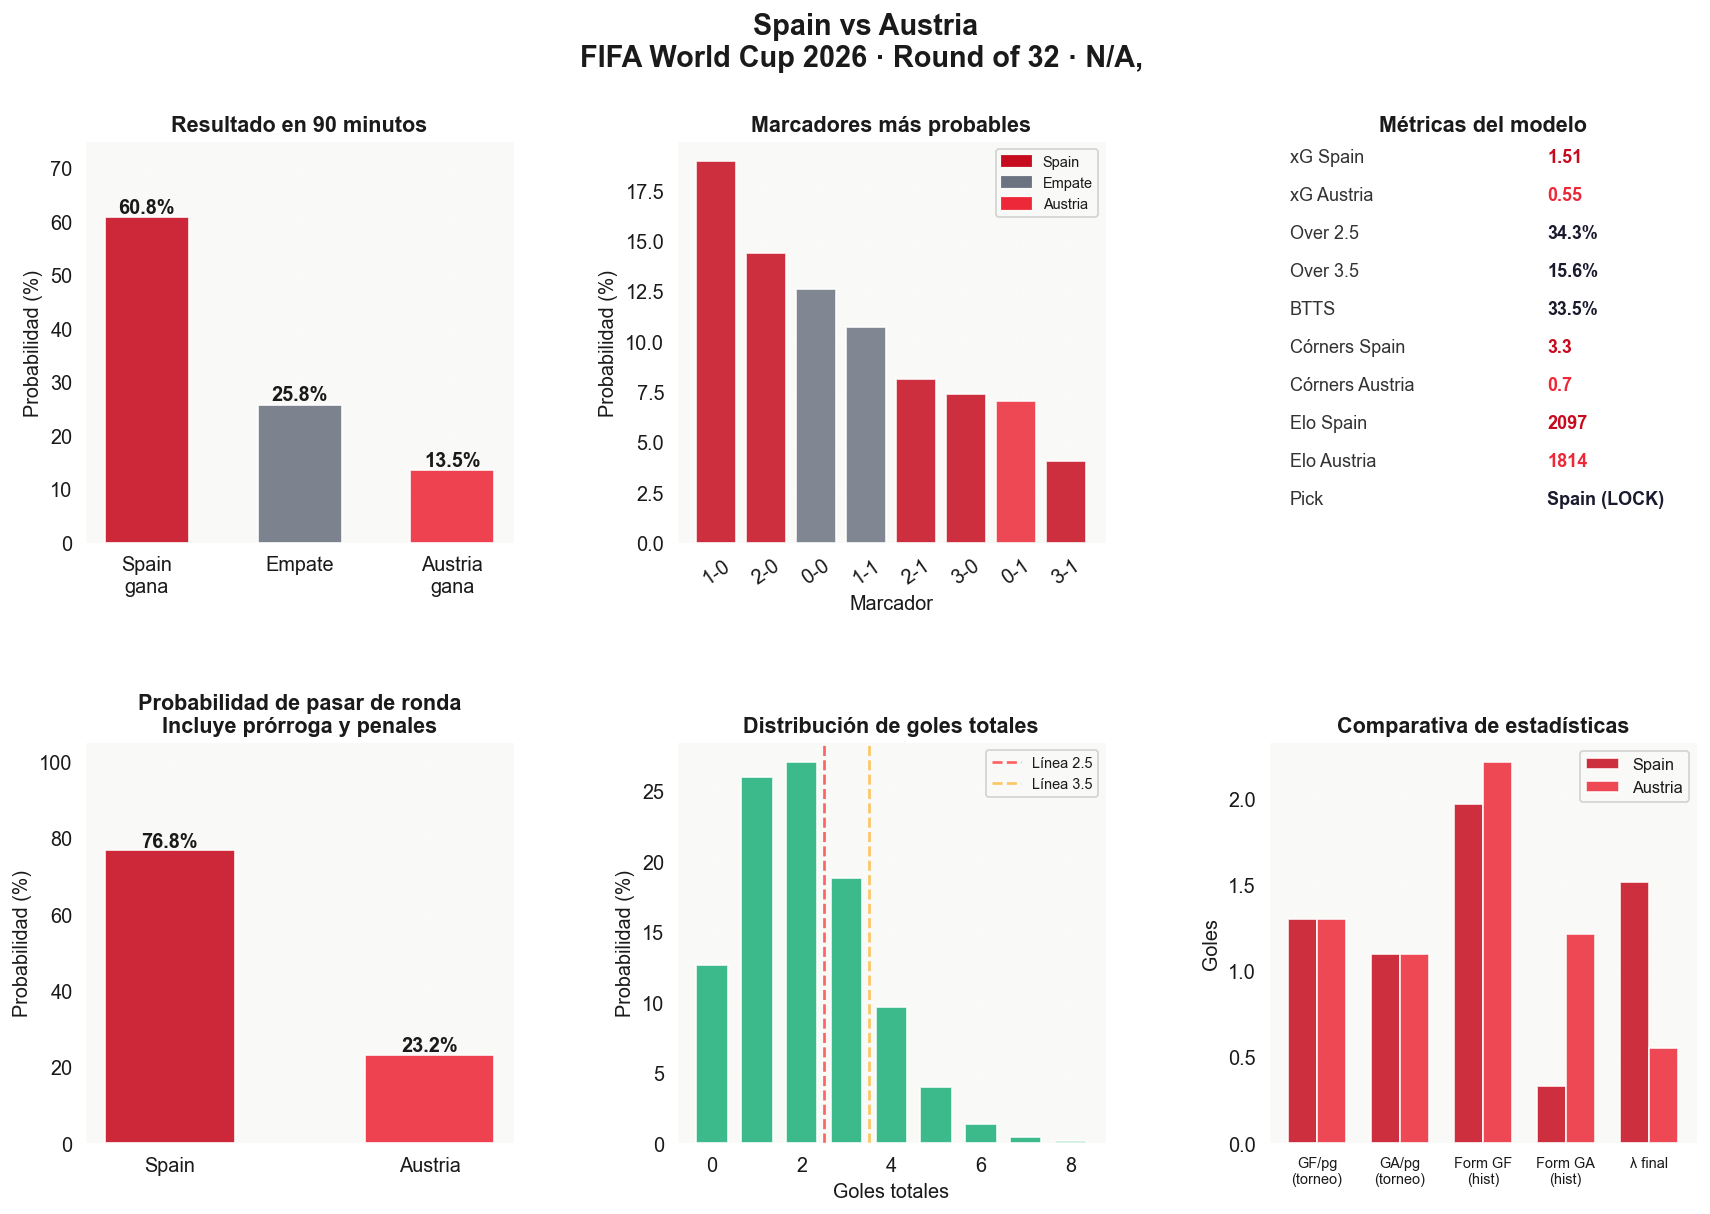

✓ Guardado: Spain_vs_Austria_2026-07-02.png

  Spain vs Austria
  Round of 32 · N/A · 2026-07-02
  λ Spain  1.515   λ Austria 0.553
  Elo Spain  2097    Elo Austria 1814
----------------------------------------------------------
  Spain gana (90 min)   60.8%
  Empate (90 min)             25.8%
  Austria gana (90 min)   13.5%
----------------------------------------------------------
  Spain pasa de ronda   76.8%
  Austria pasa de ronda   23.2%
----------------------------------------------------------
  Over 2.5   34.3%   |   BTTS   33.5%
  PICK: Spain — LOCK

############################################################
#  Portugal vs Croatia
############################################################



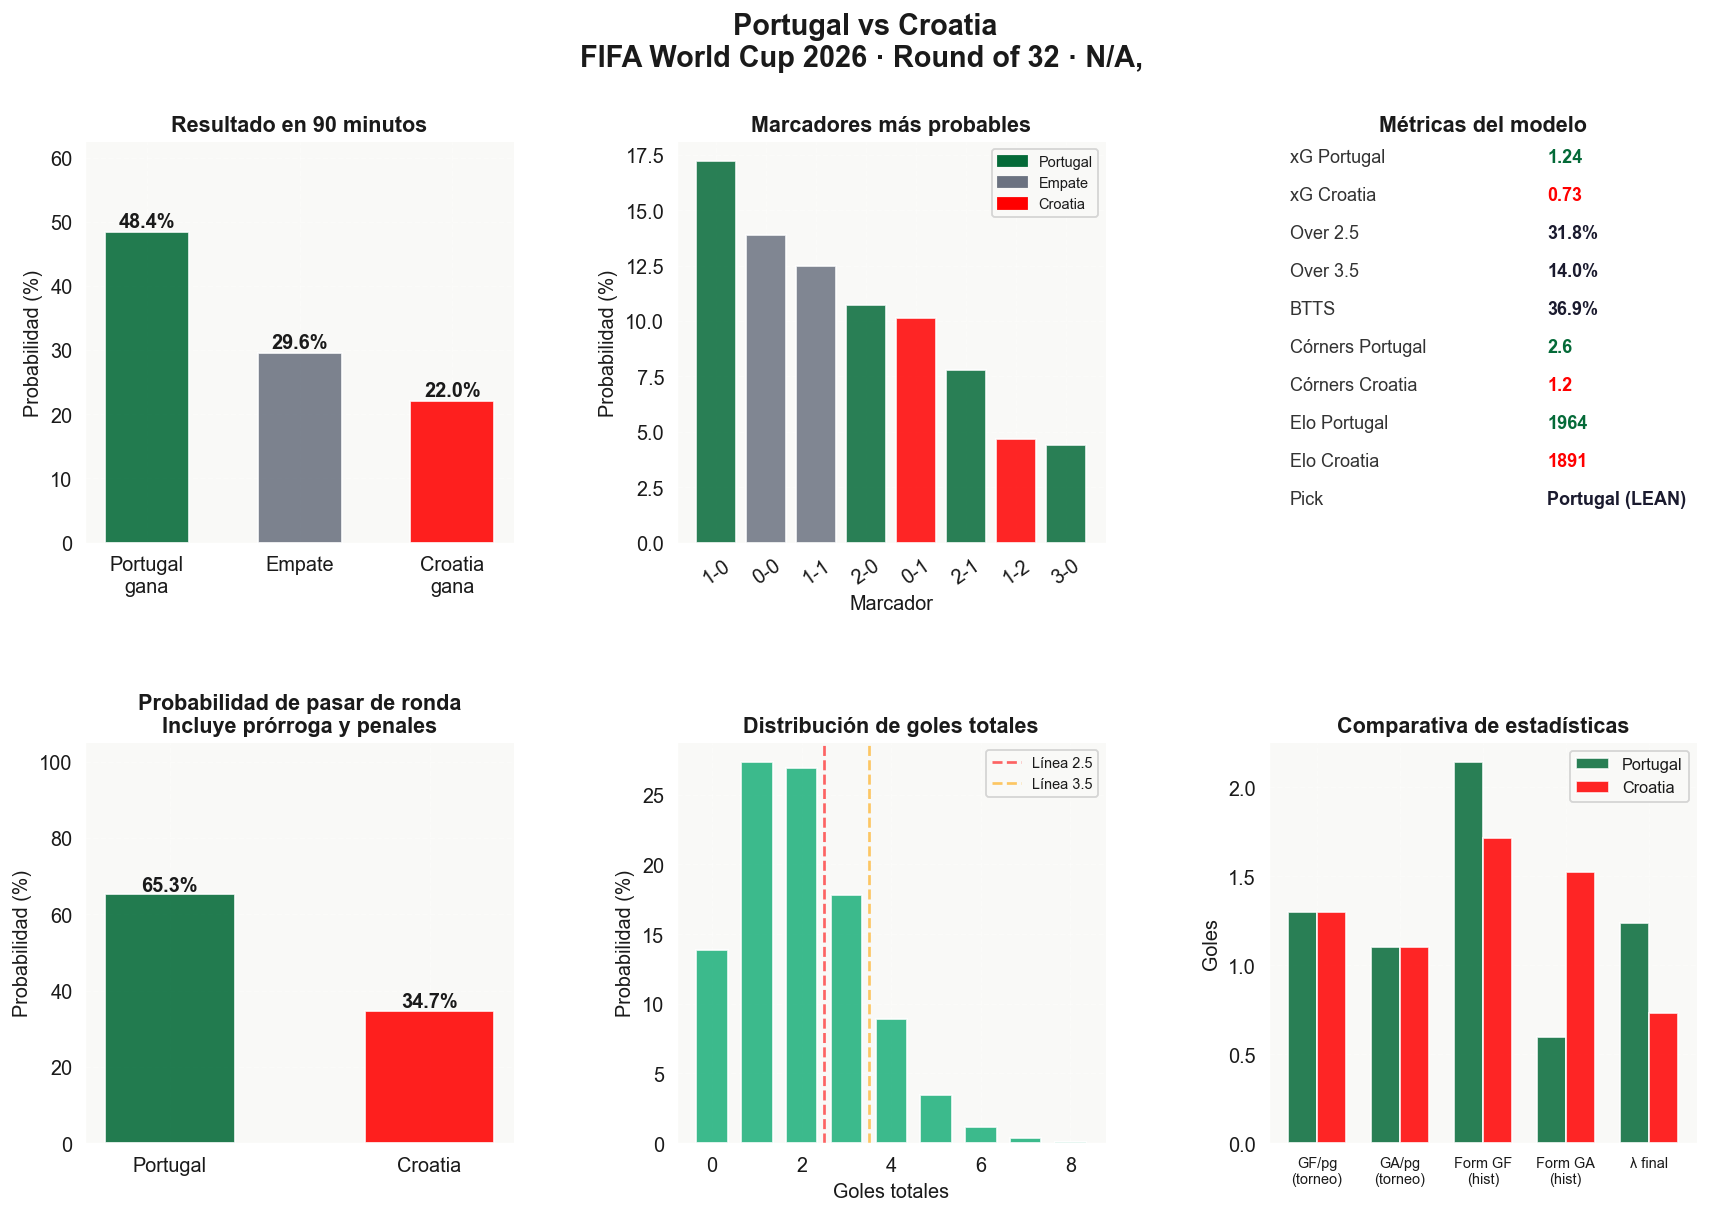

✓ Guardado: Portugal_vs_Croatia_2026-07-02.png

  Portugal vs Croatia
  Round of 32 · N/A · 2026-07-02
  λ Portugal  1.240   λ Croatia 0.732
  Elo Portugal  1964    Elo Croatia 1891
----------------------------------------------------------
  Portugal gana (90 min)   48.4%
  Empate (90 min)             29.6%
  Croatia gana (90 min)   22.0%
----------------------------------------------------------
  Portugal pasa de ronda   65.3%
  Croatia pasa de ronda   34.7%
----------------------------------------------------------
  Over 2.5   31.8%   |   BTTS   36.9%
  PICK: Portugal — LEAN

############################################################
#  Switzerland vs Algeria
############################################################



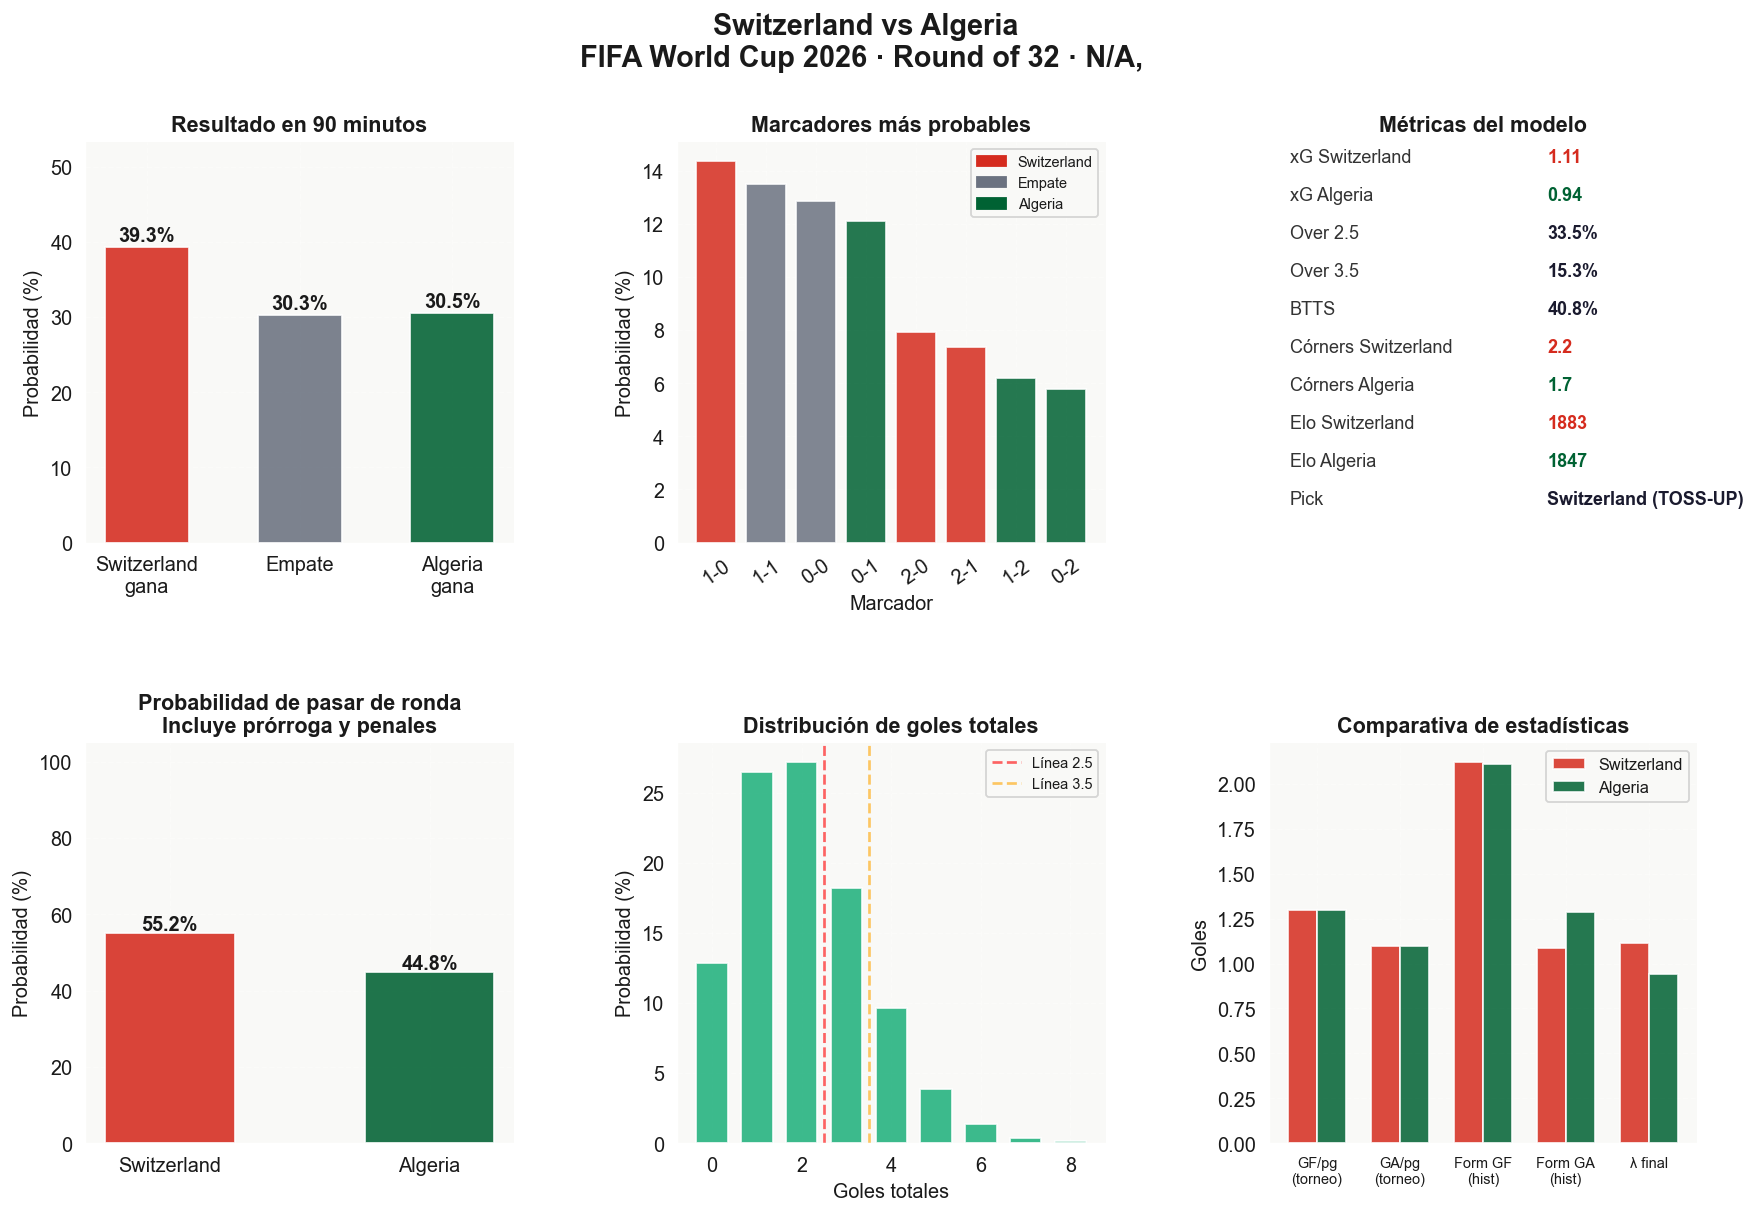

✓ Guardado: Switzerland_vs_Algeria_2026-07-02.png

  Switzerland vs Algeria
  Round of 32 · N/A · 2026-07-02
  λ Switzerland  1.114   λ Algeria 0.943
  Elo Switzerland  1883    Elo Algeria 1847
----------------------------------------------------------
  Switzerland gana (90 min)   39.3%
  Empate (90 min)             30.3%
  Algeria gana (90 min)   30.5%
----------------------------------------------------------
  Switzerland pasa de ronda   55.2%
  Algeria pasa de ronda   44.8%
----------------------------------------------------------
  Over 2.5   33.5%   |   BTTS   40.8%
  PICK: Switzerland — TOSS-UP


In [21]:
# ── Correr el predictor para los 3 partidos de hoy ───────────────────────────
palette = [('#C60B1E','#ED2939'), ('#046A38','#FF0000'), ('#D52B1E','#006233')]
# Rojo España / Rojo Austria · Verde Portugal / Rojo Croacia · Rojo Suiza / Verde Argelia

results = []
for (h, a), C in zip(MATCHES_TODAY, palette):
    print(f"\n{'#'*60}\n#  {h} vs {a}\n{'#'*60}\n")
    results.append(simulate_match(h, a, C=C))


In [19]:
# ── Resumen consolidado de los 3 partidos ────────────────────────────────────
summary = pd.DataFrame([{
    'Partido': f"{r['home']} vs {r['away']}",
    f'P(Home)': f"{r['p_h']:.1%}",
    'P(Empate)': f"{r['p_d']:.1%}",
    'P(Away)': f"{r['p_a']:.1%}",
    'Pasa Home': f"{r['p_h_total']:.1%}",
    'Pasa Away': f"{r['p_a_total']:.1%}",
    'Marcador top': f"{r['top_score']} ({r['top_score_prob']:.1%})",
    'Pick': f"{r['pick']} ({r['tag']})",
} for r in results])

print(f"Resumen · Round of 32 · {TODAY}\n")
summary


Resumen · Round of 32 · 2026-07-02



,Partido,P(Home),P(Empate),P(Away),Pasa Home,Pasa Away,Marcador top,Pick
0,Spain vs Austria,60.9%,25.7%,13.3%,76.9%,23.1%,1-0 (19.2%),Spain (LOCK)
1,Portugal vs Croatia,48.2%,29.9%,22.0%,65.2%,34.8%,1-0 (17.3%),Portugal (LEAN)
2,Switzerland vs Algeria,39.4%,30.2%,30.4%,55.3%,44.7%,1-0 (14.3%),Switzerland (TOSS-UP)


**Cómo interpretar el PICK:** `LOCK` (≥60%) alta confianza · `LEAN` (45–60%) favorito moderado ·
`TOSS-UP` (<45%) demasiado parejo.

**Antes de cada partido:** vuelve a correr la celda de alineaciones ~1h antes del kickoff, y si hay
una baja confirmada ajusta `INJURY_FACTOR['Nombre del equipo']` en la celda 6 antes de re-ejecutar
`simulate_match(...)`.

**Para agregar más partidos** (ej. mañana: Australia-Egipto, Argentina-Cabo Verde, Colombia-Ghana),
solo agrega las tuplas a `MATCHES_TODAY` en la celda de configuración y vuelve a correr desde ahí —
no hay que tocar ninguna otra celda.
